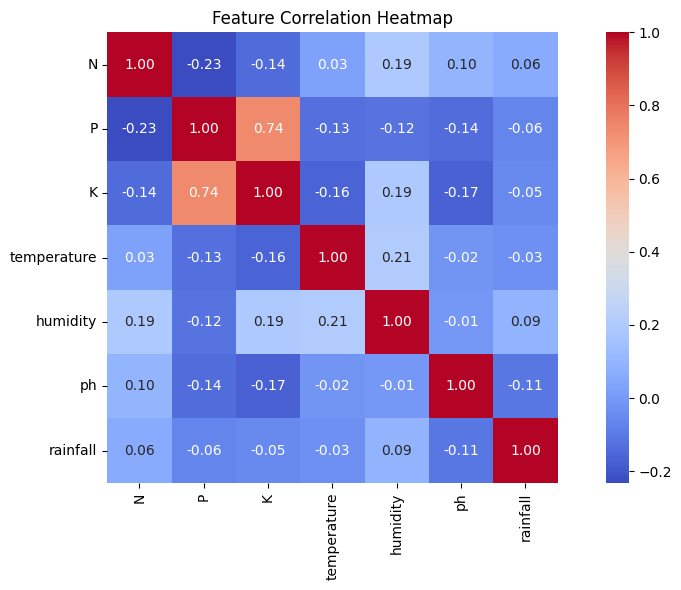

In [ ]:
# Correlation HeatMap
plt.figure(figsize=(10, 6))
sns.heatmap(
    df[features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
#EDA starts
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nStatistical Summary:")
print(df.describe())

Shape: (2200, 9)

First 5 rows:
    N   P   K  temperature   humidity        ph    rainfall label  \
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice   
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice   
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice   
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice   
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice   

   Crop_Encoded  
0            20  
1            20  
2            20  
3            20  
4            20  

Data Types:
N                 int64
P                 int64
K                 int64
temperature     float64
humidity        float64
ph              float64
rainfall        float64
label            object
Crop_Encoded      int64
dtype: object

Missing Values:
N               0
P               0
K               0
temperature     0
humidity        0
ph              0
rainfall        0
label           0
Crop_Encoded    0
dtype: int64

Duplicate

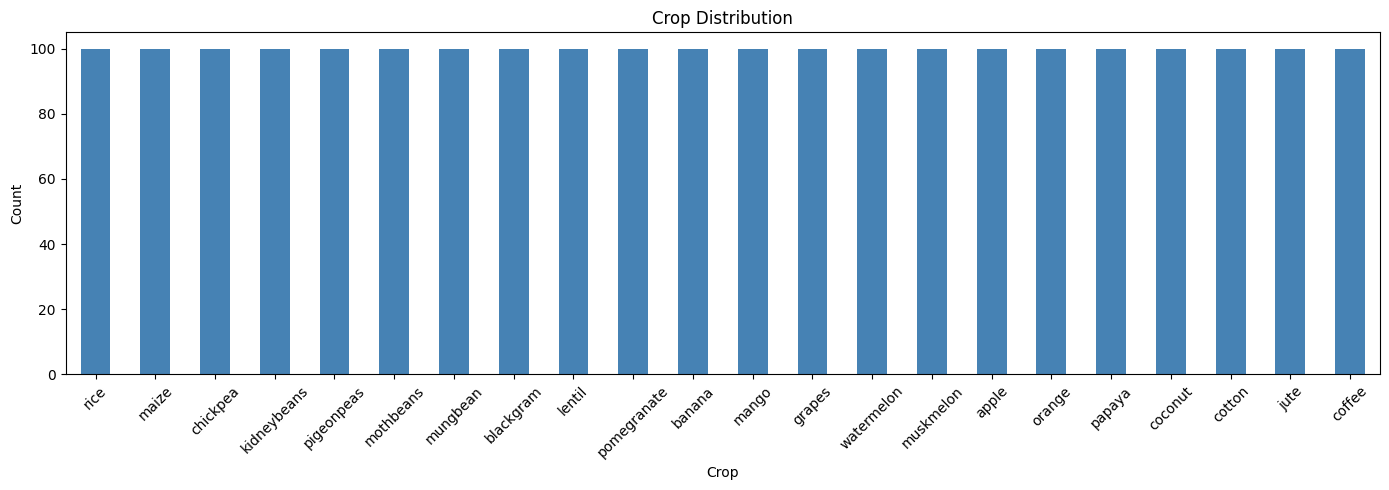

In [ ]:
#Crop distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))
df['label'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

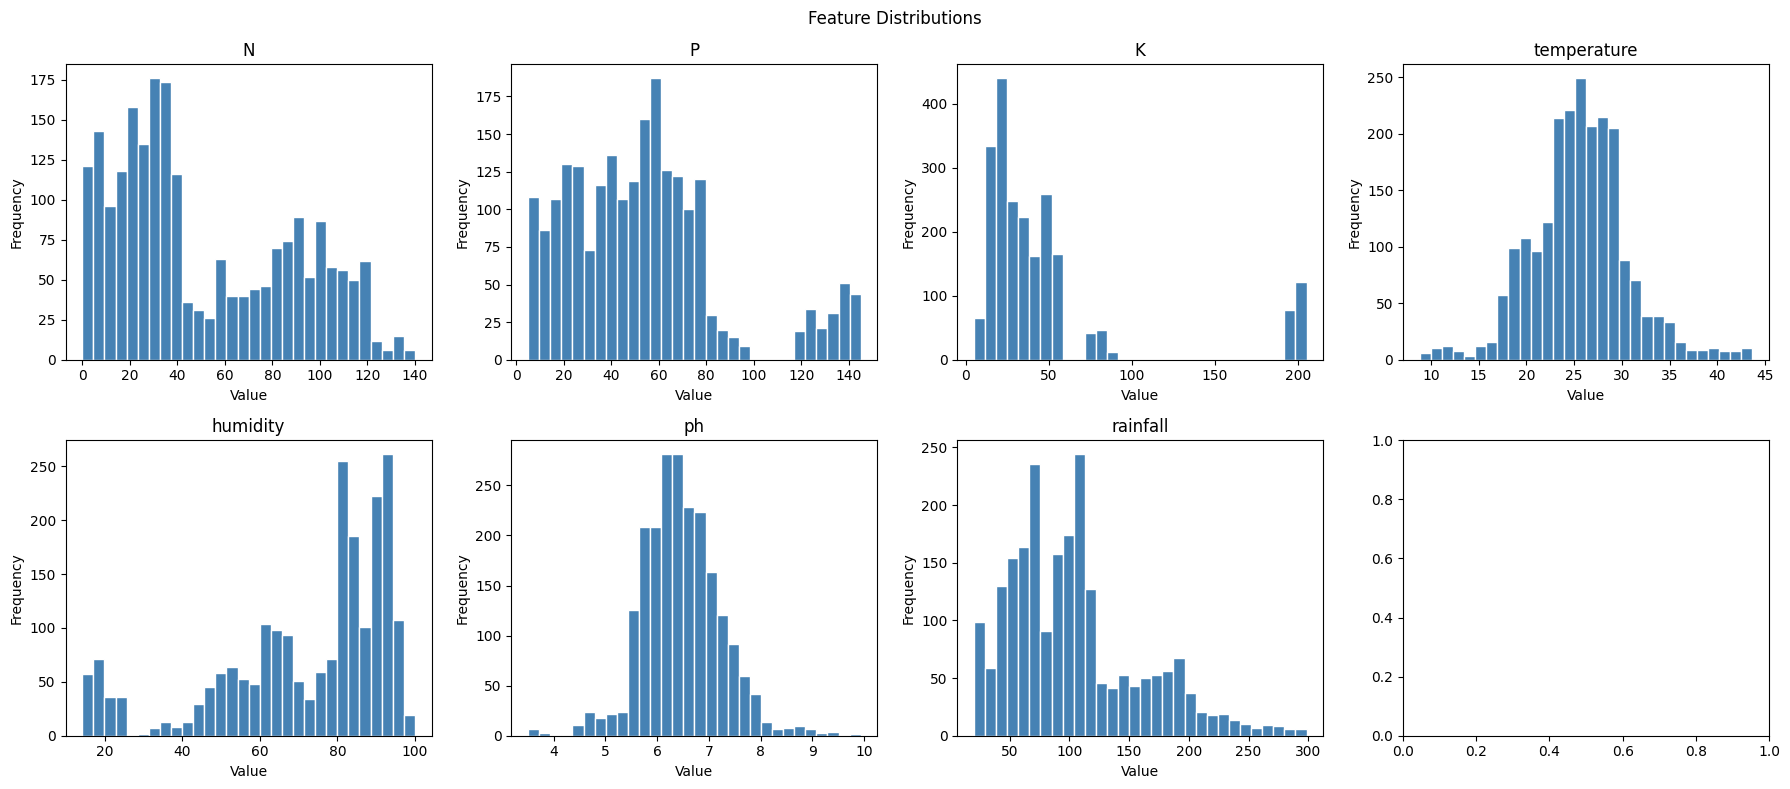

In [ ]:
#Feature distribution
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

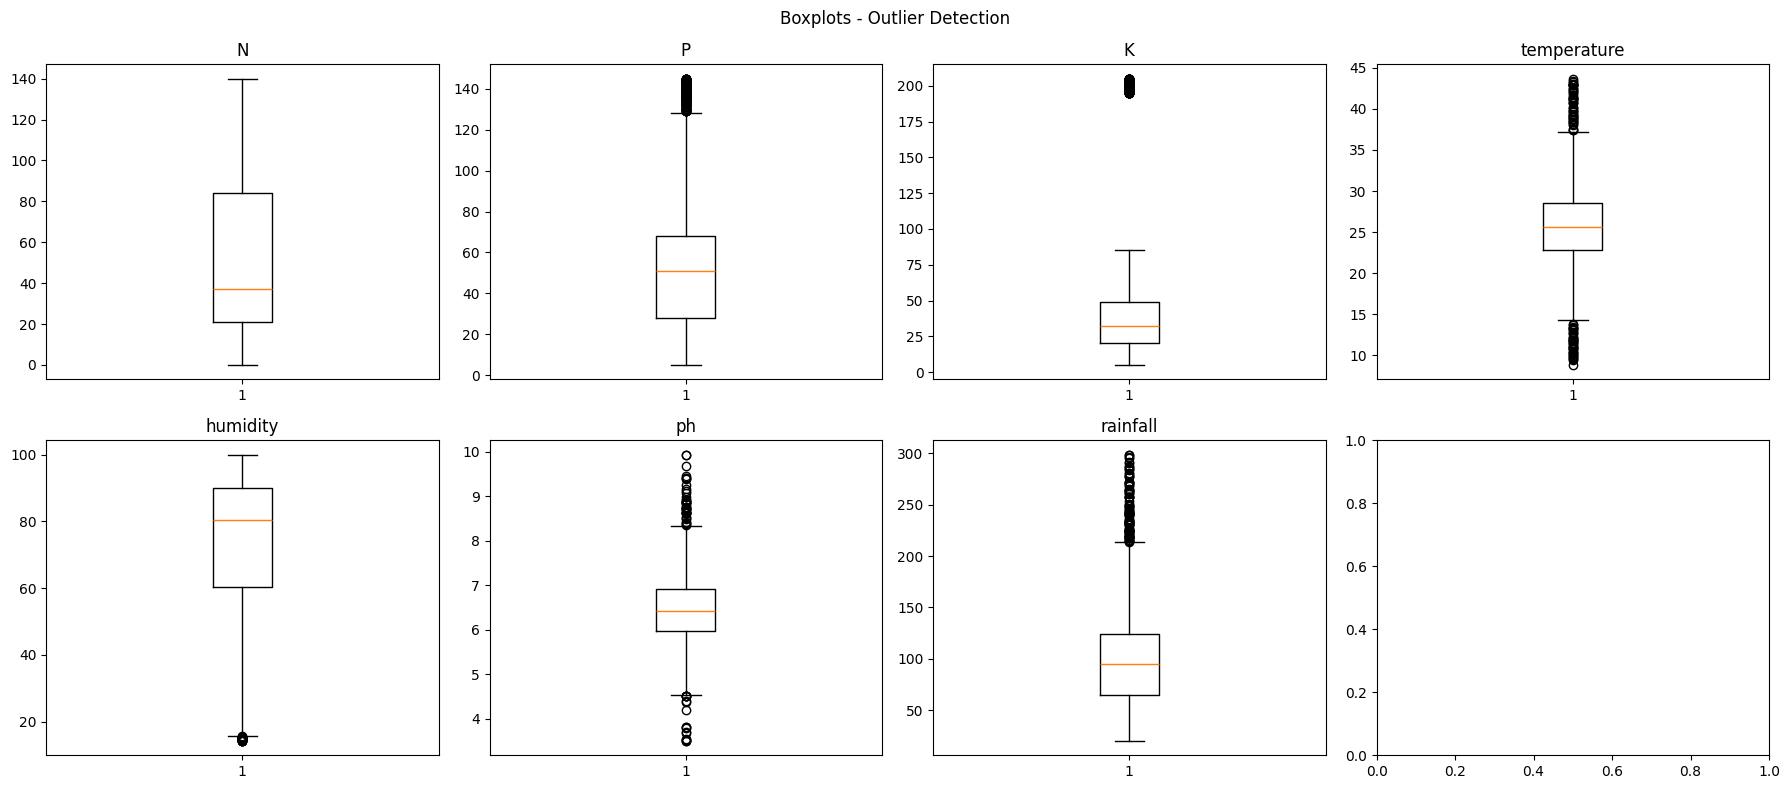

In [ ]:
#outlier detection
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.suptitle("Boxplots - Outlier Detection")
plt.tight_layout()
plt.show()

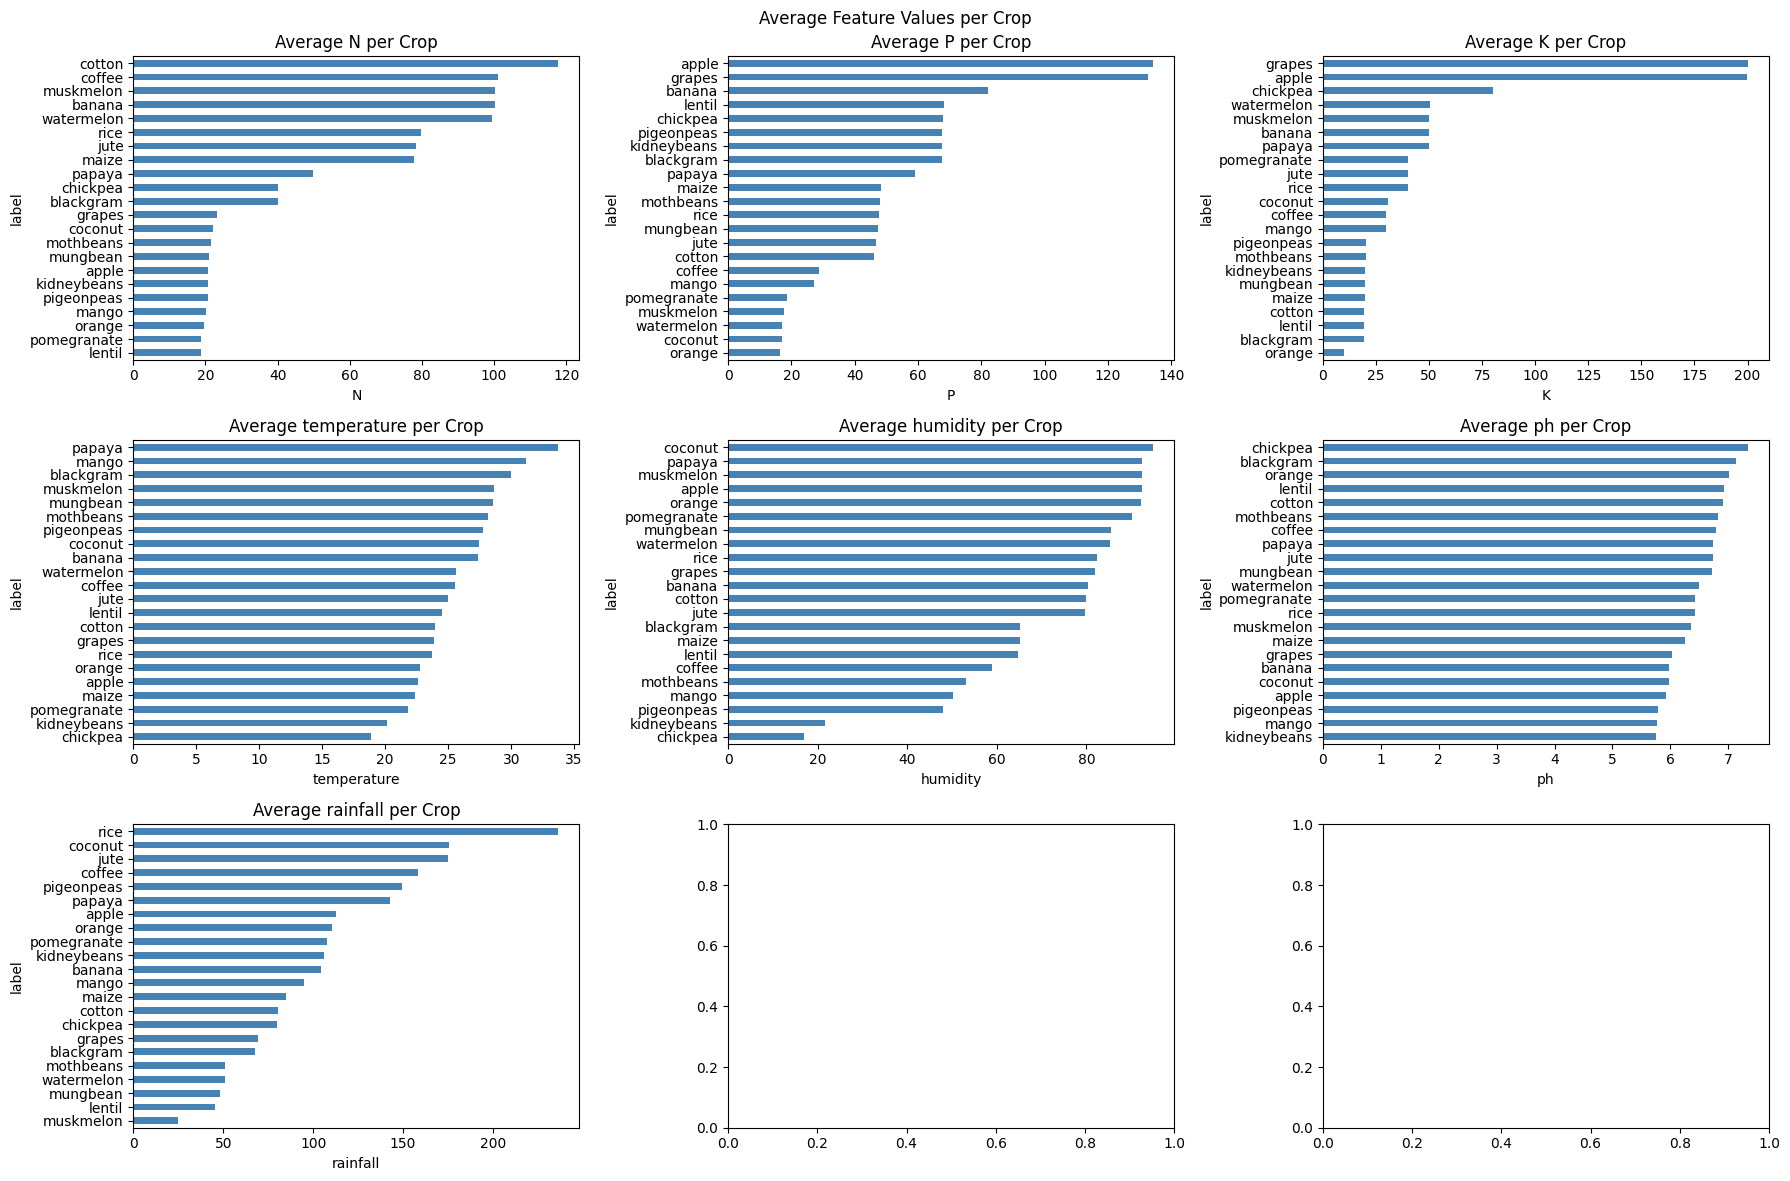

In [ ]:
#Feature vs Crop
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    df.groupby('label')[col].mean().sort_values().plot(
        kind='barh', ax=axes[i], color='steelblue'
    )
    axes[i].set_title(f"Average {col} per Crop")
    axes[i].set_xlabel(col)

plt.suptitle("Average Feature Values per Crop")
plt.tight_layout()
plt.show()

In [ ]:
#Crop count summary
crop_counts = df['label'].value_counts()
print(crop_counts.head(10))
print(f"\nTotal unique crops: {len(crop_counts)}")

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
Name: count, dtype: int64

Total unique crops: 22


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get predictions
y_pred = pipeline.predict(X_test)

# Decode numbers back to crop names
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# Actual vs Predicted DataFrame
import pandas as pd
results = pd.DataFrame({
    'Actual': y_test_labels,
    'Predicted': y_pred_labels,
    'Correct': y_test_labels == y_pred_labels
})

print(results.head(20))
print(f"\nTotal Correct: {results['Correct'].sum()} / {len(results)}")
print(f"Accuracy: {results['Correct'].mean() * 100:.2f}%")

         Actual    Predicted  Correct
0        orange       orange     True
1        banana       banana     True
2        cotton       cotton     True
3         maize        maize     True
4        orange       orange     True
5      chickpea     chickpea     True
6          rice         rice     True
7     blackgram    blackgram     True
8        banana       banana     True
9        orange       orange     True
10   watermelon   watermelon     True
11  pomegranate  pomegranate     True
12   watermelon   watermelon     True
13        maize        maize     True
14    mothbeans    mothbeans     True
15       grapes       grapes     True
16       grapes       grapes     True
17        mango        mango     True
18        mango        mango     True
19        apple        apple     True

Total Correct: 438 / 440
Accuracy: 99.55%


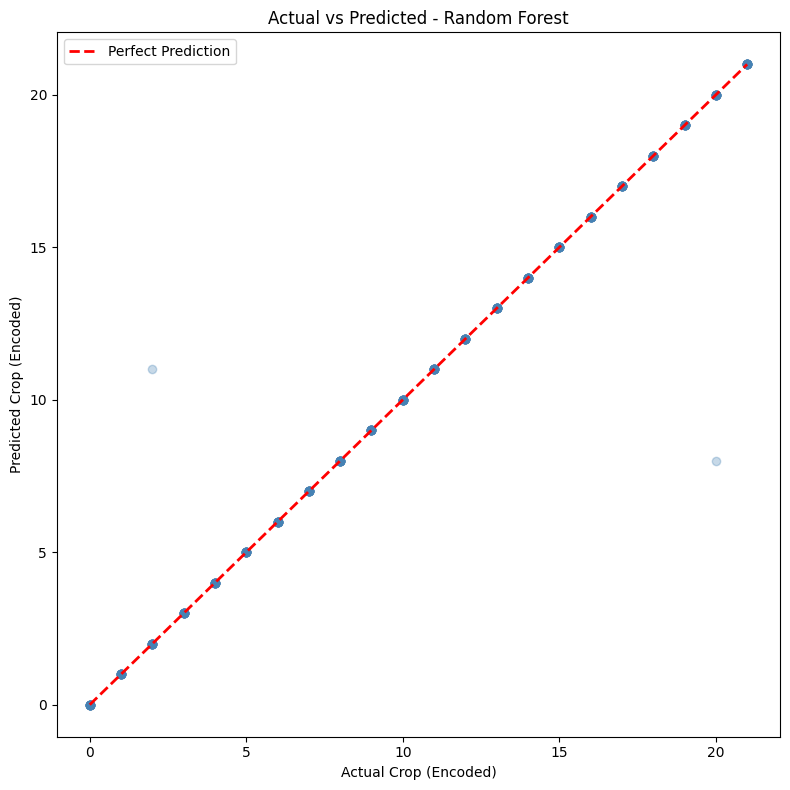

In [ ]:
# Encode for scatter plot
actual_encoded = y_test.values
predicted_encoded = y_pred

plt.figure(figsize=(8, 8))
plt.scatter(actual_encoded, predicted_encoded, alpha=0.3, color='steelblue')
plt.plot([0, 21], [0, 21], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual Crop (Encoded)")
plt.ylabel("Predicted Crop (Encoded)")
plt.title("Actual vs Predicted - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

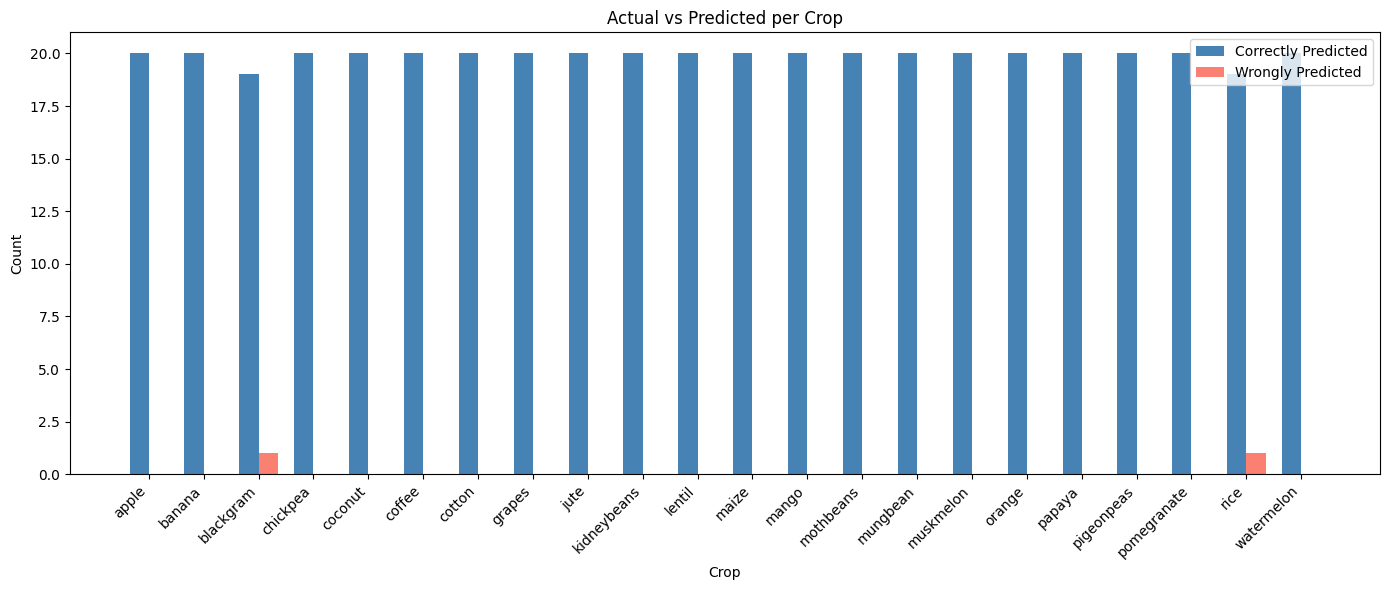

In [ ]:
# Count correct vs wrong per crop
summary = results.groupby('Actual')['Correct'].agg(['sum', 'count'])
summary.columns = ['Correct', 'Total']
summary['Wrong'] = summary['Total'] - summary['Correct']

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(summary))
width = 0.35

bars1 = ax.bar(x - width/2, summary['Correct'], width,
               label='Correctly Predicted', color='steelblue')
bars2 = ax.bar(x + width/2, summary['Wrong'], width,
               label='Wrongly Predicted', color='salmon')

ax.set_xlabel("Crop")
ax.set_ylabel("Count")
ax.set_title("Actual vs Predicted per Crop")
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('/content/app.py', '/content/drive/MyDrive/app.py')
shutil.copy('/content/crop_recommendation_model.pkl', '/content/drive/MyDrive/crop_recommendation_model.pkl')
shutil.copy('/content/label_encoder.pkl', '/content/drive/MyDrive/label_encoder.pkl')
print("All files saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All files saved to Google Drive!
